# Converting customer segmentation results into practical marketing strategies.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)

In [5]:
PROCESSED=Path("data/processed")

In [6]:
df=pd.read_csv(PROCESSED/"customer_segments.csv")
print("Rows:", len(df))

Rows: 16865


In [7]:
persona_table=pd.read_csv(PROCESSED / "customer_personas.csv")
persona_table

,cluster,total_orders,total_revenue,average_order_value,avg_discount_percent,return_rate,total_sessions,customer_lifetime_value,loyalty_score,preferred_payment,favorite_category,city_tier,preferred_device,preferred_traffic_source
0,0,1.23,3100.50,2517.34,15.88,0.35,0.00,3100.50,1.59,Card,shirts,Mumbai / Tier 1,Unknown,Unknown
1,1,3.18,8204.21,2605.61,15.88,0.35,2.91,8204.21,7.81,Card,shirts,Mumbai / Tier 1,mobile,Meta
2,2,1.30,3224.09,2491.78,15.63,0.35,1.45,3224.09,1.71,Card,shirts,Mumbai / Tier 1,mobile,Meta


In [8]:
df.head()

,customer_id,total_orders,total_revenue,average_order_value,median_spend,max_spend,total_discount,avg_discount_percent,completed_orders,returned_orders,rto_orders,payment_diversity,category_diversity,size_diversity,color_diversity,vendor_diversity,return_rate,total_sessions,total_product_views,total_add_to_cart,total_checkout,total_purchases,website_revenue,view_to_cart_rate,cart_to_checkout_rate,checkout_to_purchase_rate,revenue_per_session,customer_lifetime_value,loyalty_score,cluster
0,CUST-0000001,1,3356.0,3356.0,3356.0,3356,307,8.40,0,1,0,1,2,2,2,2,1.0,1.0,4.0,1.0,1.0,1.0,3356.0,0.250000,1.0,1.0,3356.0,3356.0,1,2
1,CUST-0000003,1,2360.0,2360.0,2360.0,2360,125,5.00,1,0,0,1,1,1,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2360.0,1,0
2,CUST-0000004,2,4029.0,2014.5,2014.5,2291,832,17.50,0,2,0,1,2,3,3,3,1.0,4.0,11.0,4.0,4.0,4.0,8058.0,0.363636,1.0,1.0,2014.5,4029.0,2,2
3,CUST-0000005,1,2581.0,2581.0,2581.0,2581,1003,28.00,1,0,0,1,2,1,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2581.0,1,0
4,CUST-0000007,2,5365.0,2682.5,2682.5,2994,1314,19.95,0,1,1,2,3,3,2,3,1.0,2.0,4.0,2.0,2.0,2.0,5365.0,0.500000,1.0,1.0,2682.5,5365.0,4,1


In [9]:
segment_size=(
    df["cluster"]
    .value_counts()
    .sort_index()
)
segment_size

cluster
0    4277
1    4450
2    8138
Name: count, dtype: int64

In [10]:
segment_percentage=(
    df["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)
segment_percentage

cluster
0    25.36
1    26.39
2    48.25
Name: proportion, dtype: float64

### Summary:

In [11]:
segment_summary=pd.DataFrame({
    "customers": segment_size,
    "customer_percentage": segment_percentage
})
segment_summary

,customers,customer_percentage
cluster,,
0,4277,25.36
1,4450,26.39
2,8138,48.25


### Segment size chart:

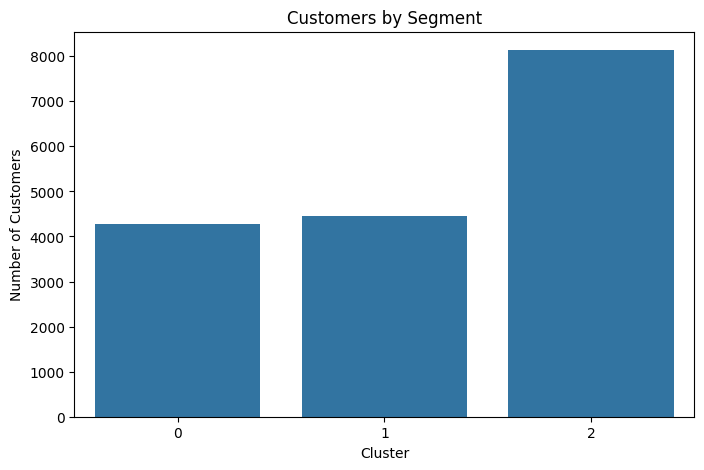

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_summary.index,
    y=segment_summary["customers"]
)

plt.title("Customers by Segment")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

### Revenue by Segment:

In [13]:
revenue_summary=(
    df.groupby("cluster")["total_revenue"]
    .agg(["sum", "mean"])
    .round(2)
)

revenue_summary.columns=[
    "total_revenue",
    "average_revenue_per_customer"
]
revenue_summary

,total_revenue,average_revenue_per_customer
cluster,,
0,13260832.0,3100.50
1,36508733.0,8204.21
2,26237612.0,3224.09


### Revenue contribution:

In [14]:
total_revenue=df["total_revenue"].sum()

revenue_summary["revenue_percentage"]=(
    revenue_summary["total_revenue"]
    / total_revenue
    * 100
).round(2)
revenue_summary

,total_revenue,average_revenue_per_customer,revenue_percentage
cluster,,,
0,13260832.0,3100.50,17.45
1,36508733.0,8204.21,48.03
2,26237612.0,3224.09,34.52


### Reveunue chart:

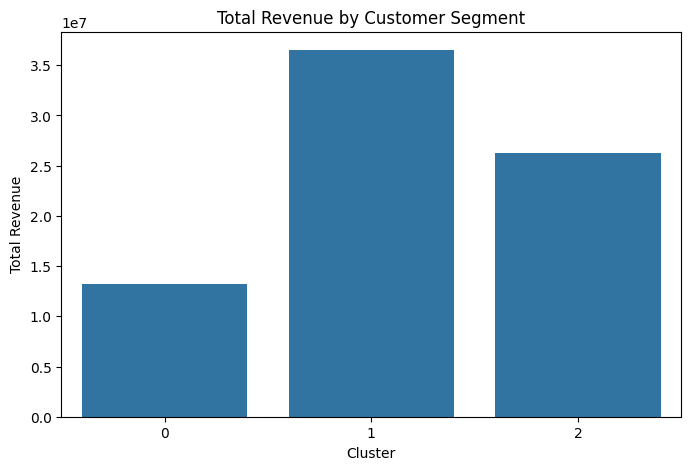

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=revenue_summary.index,
    y=revenue_summary["total_revenue"]
)

plt.title("Total Revenue by Customer Segment")
plt.xlabel("Cluster")
plt.ylabel("Total Revenue")
plt.show()

### Customer value:

In [16]:
value_summary=(
    df.groupby("cluster")[
        [
            "average_order_value",
            "customer_lifetime_value",
            "loyalty_score",
            "total_orders"
        ]
    ]
    .mean()
    .round(2)
)
value_summary

,average_order_value,customer_lifetime_value,loyalty_score,total_orders
cluster,,,,
0,2517.34,3100.50,1.59,1.23
1,2605.61,8204.21,7.81,3.18
2,2491.78,3224.09,1.71,1.30


### Segment comparison:

In [17]:
business_summary=segment_summary.join(
    revenue_summary
).join(
    value_summary
)
business_summary

,customers,customer_percentage,total_revenue,average_revenue_per_customer,revenue_percentage,average_order_value,customer_lifetime_value,loyalty_score,total_orders
cluster,,,,,,,,,
0,4277,25.36,13260832.0,3100.50,17.45,2517.34,3100.50,1.59,1.23
1,4450,26.39,36508733.0,8204.21,48.03,2605.61,8204.21,7.81,3.18
2,8138,48.25,26237612.0,3224.09,34.52,2491.78,3224.09,1.71,1.30


### Assigning personas:

In [18]:
persona_names={
    0: "Low-Engagement Customers",
    1: "High-Value Loyal Customers",
    2: "Potential Repeat Customers"
}

business_summary["persona"]=(
    business_summary.index
    .map(persona_names)
)
business_summary

,customers,customer_percentage,total_revenue,average_revenue_per_customer,revenue_percentage,average_order_value,customer_lifetime_value,loyalty_score,total_orders,persona
cluster,,,,,,,,,,
0,4277,25.36,13260832.0,3100.50,17.45,2517.34,3100.50,1.59,1.23,Low-Engagement Customers
1,4450,26.39,36508733.0,8204.21,48.03,2605.61,8204.21,7.81,3.18,High-Value Loyal Customers
2,8138,48.25,26237612.0,3224.09,34.52,2491.78,3224.09,1.71,1.30,Potential Repeat Customers


### Campaign objectives:

In [19]:
campaign_objective={
    0: "Reactivate customers",
    1: "Retain and reward customers",
    2: "Encourage repeat purchases"
}

business_summary["campaign_objective"]=(
    business_summary.index
    .map(campaign_objective)
)
business_summary

,customers,customer_percentage,total_revenue,average_revenue_per_customer,revenue_percentage,average_order_value,customer_lifetime_value,loyalty_score,total_orders,persona,campaign_objective
cluster,,,,,,,,,,,
0,4277,25.36,13260832.0,3100.50,17.45,2517.34,3100.50,1.59,1.23,Low-Engagement Customers,Reactivate customers
1,4450,26.39,36508733.0,8204.21,48.03,2605.61,8204.21,7.81,3.18,High-Value Loyal Customers,Retain and reward customers
2,8138,48.25,26237612.0,3224.09,34.52,2491.78,3224.09,1.71,1.30,Potential Repeat Customers,Encourage repeat purchases


### Recommended Strategy:

In [20]:
campaign_strategy={
    0: "Re-engagement campaigns with personalized offers and reminders",
    1: "VIP loyalty programs, early access and personalized recommendations",
    2: "Repeat-purchase offers, product recommendations and retargeting"
}

business_summary["recommended_strategy"]=(
    business_summary.index
    .map(campaign_strategy)
)
business_summary

,customers,customer_percentage,total_revenue,average_revenue_per_customer,revenue_percentage,average_order_value,customer_lifetime_value,loyalty_score,total_orders,persona,campaign_objective,recommended_strategy
cluster,,,,,,,,,,,,
0,4277,25.36,13260832.0,3100.50,17.45,2517.34,3100.50,1.59,1.23,Low-Engagement Customers,Reactivate customers,Re-engagement campaigns with personalized offe...
1,4450,26.39,36508733.0,8204.21,48.03,2605.61,8204.21,7.81,3.18,High-Value Loyal Customers,Retain and reward customers,"VIP loyalty programs, early access and persona..."
2,8138,48.25,26237612.0,3224.09,34.52,2491.78,3224.09,1.71,1.30,Potential Repeat Customers,Encourage repeat purchases,"Repeat-purchase offers, product recommendation..."


### Complete campaign plan:

In [21]:
campaign_plan=business_summary[
    [
        "persona",
        "customers",
        "customer_percentage",
        "total_revenue",
        "revenue_percentage",
        "average_revenue_per_customer",
        "loyalty_score",
        "campaign_objective",
        "recommended_strategy"
    ]
]
campaign_plan

,persona,customers,customer_percentage,total_revenue,revenue_percentage,average_revenue_per_customer,loyalty_score,campaign_objective,recommended_strategy
cluster,,,,,,,,,
0,Low-Engagement Customers,4277,25.36,13260832.0,17.45,3100.50,1.59,Reactivate customers,Re-engagement campaigns with personalized offe...
1,High-Value Loyal Customers,4450,26.39,36508733.0,48.03,8204.21,7.81,Retain and reward customers,"VIP loyalty programs, early access and persona..."
2,Potential Repeat Customers,8138,48.25,26237612.0,34.52,3224.09,1.71,Encourage repeat purchases,"Repeat-purchase offers, product recommendation..."


### Finalized table:

In [22]:
campaign_plan[
    [
        "persona",
        "campaign_objective",
        "recommended_strategy"
    ]
]

,persona,campaign_objective,recommended_strategy
cluster,,,
0,Low-Engagement Customers,Reactivate customers,Re-engagement campaigns with personalized offe...
1,High-Value Loyal Customers,Retain and reward customers,"VIP loyalty programs, early access and persona..."
2,Potential Repeat Customers,Encourage repeat purchases,"Repeat-purchase offers, product recommendation..."


### Priority ranking:

In [23]:
priority=(
    business_summary
    .sort_values(
        "revenue_percentage",
        ascending=False
    )
    [
        [
            "persona",
            "customers",
            "total_revenue",
            "revenue_percentage",
            "loyalty_score"
        ]
    ]
)
priority

,persona,customers,total_revenue,revenue_percentage,loyalty_score
cluster,,,,,
1,High-Value Loyal Customers,4450,36508733.0,48.03,7.81
2,Potential Repeat Customers,8138,26237612.0,34.52,1.71
0,Low-Engagement Customers,4277,13260832.0,17.45,1.59


### Revenue contribution chart:

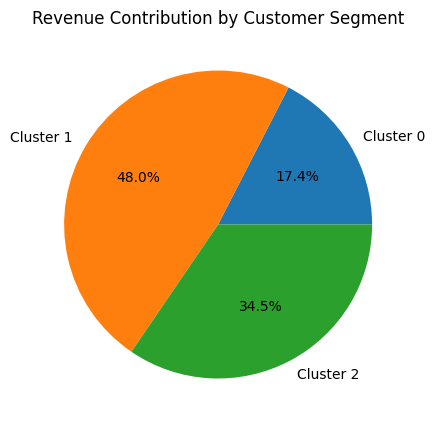

In [25]:
plt.figure(figsize=(8,5))

plt.pie(
    revenue_summary["total_revenue"],
    labels=[
        f"Cluster {i}"
        for i in revenue_summary.index
    ],
    autopct="%1.1f%%"
)

plt.title("Revenue Contribution by Customer Segment")
plt.show()

### Customer vs Revenue contribution:

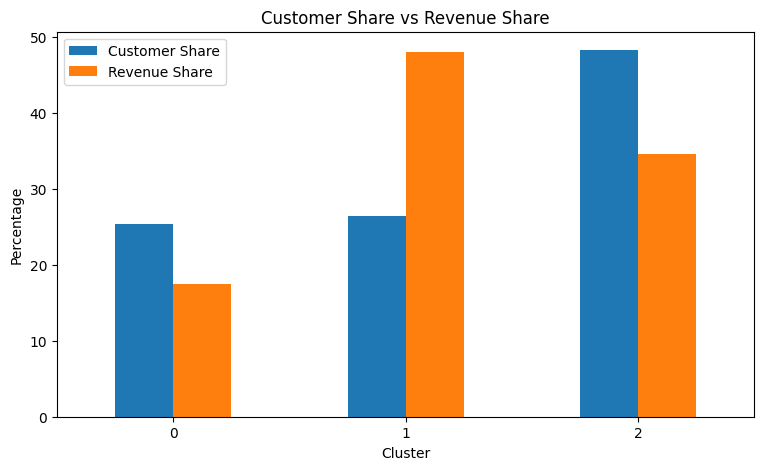

In [26]:
comparison=business_summary[
    [
        "customer_percentage",
        "revenue_percentage"
    ]
]

comparison.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Customer Share vs Revenue Share")
plt.xlabel("Cluster")
plt.ylabel("Percentage")

plt.xticks(rotation=0)
plt.legend(
    ["Customer Share", "Revenue Share"]
)
plt.show()

In [27]:
campaign_plan.to_csv(
    PROCESSED/"campaign_strategy.csv",
    index=True
)
print("Campaign strategy saved successfully..!")

Campaign strategy saved successfully..!


### Summary:

In [30]:
print("Segmentation Summary")
print("-------------------------------------")

for cluster, row in business_summary.iterrows():

    print(f"\nCluster {cluster}")
    print("Persona :", row["persona"])
    print("Customers :", row["customers"])
    print("Revenue :", round(row["total_revenue"], 2))
    print("Revenue Share :", round(row["revenue_percentage"], 2), "%")
    print("Objective :", row["campaign_objective"])

Segmentation Summary
-------------------------------------

Cluster 0
Persona : Low-Engagement Customers
Customers : 4277
Revenue : 13260832.0
Revenue Share : 17.45 %
Objective : Reactivate customers

Cluster 1
Persona : High-Value Loyal Customers
Customers : 4450
Revenue : 36508733.0
Revenue Share : 48.03 %
Objective : Retain and reward customers

Cluster 2
Persona : Potential Repeat Customers
Customers : 8138
Revenue : 26237612.0
Revenue Share : 34.52 %
Objective : Encourage repeat purchases
